<a href="https://colab.research.google.com/github/moawinds/BengKod_Alwi/blob/main/Tugas2Bengkod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Load library**

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

*Library digunakan untuk pengolahan data, modeling, dan evaluasi.*

**Load dataset**

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Unzip the dataset if it's available locally
!unzip -o /content/census+income.zip -d .

url_train = "./adult.data" # Update to local path
url_test = "./adult.test" # Update to local path

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race",
    "sex", "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df_train = pd.read_csv(url_train, names=columns, skipinitialspace=True)
df_test = pd.read_csv(url_test, names=columns, skipinitialspace=True, skiprows=1)

df = pd.concat([df_train, df_test])
df.head()

Archive:  /content/census+income.zip
  inflating: ./adult.data            
  inflating: ./adult.names           
  inflating: ./adult.test            
  inflating: ./Index                 
  inflating: ./old.adult.names       


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Menampilkan informasi dataset**

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 48842 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


*Dataset terdiri dari data numerik dan kategorik serta memiliki missing value.*

**Drop missing value**

In [6]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

Pada dataset ditemukan adanya missing value yang ditandai dengan simbol "?". Missing value ini perlu ditangani karena dapat menyebabkan error atau menurunkan performa model saat proses pelatihan.

Penanganan dilakukan dengan cara:

1.   IMengganti simbol "?" menjadi  nilai NaN
2.   Menghapus baris yang mengandung nilai kosong

Dengan demikian, data yang digunakan menjadi lebih bersih dan siap untuk diproses lebih lanjut.

**Encoding Data**

In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

**Splitting Data**

In [8]:
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Inisialisasi, Pelatihan, dan Evaluasi Model**

In [21]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Shape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of X_train after SMOTE: {X_train_res.shape}")
print(f"Class distribution of y_train before SMOTE:\n{y_train.value_counts()}")
print(f"Class distribution of y_train after SMOTE:\n{y_train_res.value_counts()}")

Shape of X_train before SMOTE: (36177, 14)
Shape of X_train after SMOTE: (72564, 14)
Class distribution of y_train before SMOTE:
income
0    18141
1     9128
2     5970
3     2938
Name: count, dtype: int64
Class distribution of y_train after SMOTE:
income
0    18141
1    18141
2    18141
3    18141
Name: count, dtype: int64


In [22]:
model_dt.fit(X_train_res, y_train_res)
model_rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced')

In [24]:
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [25]:
# Akurasi
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

# Precision
print("DT Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("RF Precision:", precision_score(y_test, y_pred_rf, average='weighted'))

# Recall
print("DT Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("RF Recall:", recall_score(y_test, y_pred_rf, average='weighted'))

# F1 Score
print("DT F1:", f1_score(y_test, y_pred_dt, average='weighted'))
print("RF F1:", f1_score(y_test, y_pred_rf, average='weighted'))

# Classification Report
print("Decision Tree\n", classification_report(y_test, y_pred_dt))
print("Random Forest\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("DT Matrix\n", confusion_matrix(y_test, y_pred_dt))
print("RF Matrix\n", confusion_matrix(y_test, y_pred_rf))

DT Accuracy: 0.4357103372028745
RF Accuracy: 0.4975124378109453
DT Precision: 0.4479017680041505
RF Precision: 0.46898145580906586
DT Recall: 0.4357103372028745
RF Recall: 0.4975124378109453
DT F1: 0.44110809704548326
RF F1: 0.4789191858649263
Decision Tree
               precision    recall  f1-score   support

           0       0.58      0.54      0.56      4513
           1       0.29      0.30      0.30      2232
           2       0.40      0.40      0.40      1538
           3       0.21      0.26      0.23       762

    accuracy                           0.44      9045
   macro avg       0.37      0.38      0.37      9045
weighted avg       0.45      0.44      0.44      9045

Random Forest
               precision    recall  f1-score   support

           0       0.60      0.69      0.64      4513
           1       0.29      0.20      0.24      2232
           2       0.47      0.54      0.50      1538
           3       0.22      0.16      0.18       762

    accuracy       

In [17]:
model_dt = DecisionTreeClassifier(class_weight='balanced')
model_rf = RandomForestClassifier(class_weight='balanced')

In [18]:
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

**Prediksi**

In [19]:
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

**Evaluasi Model**

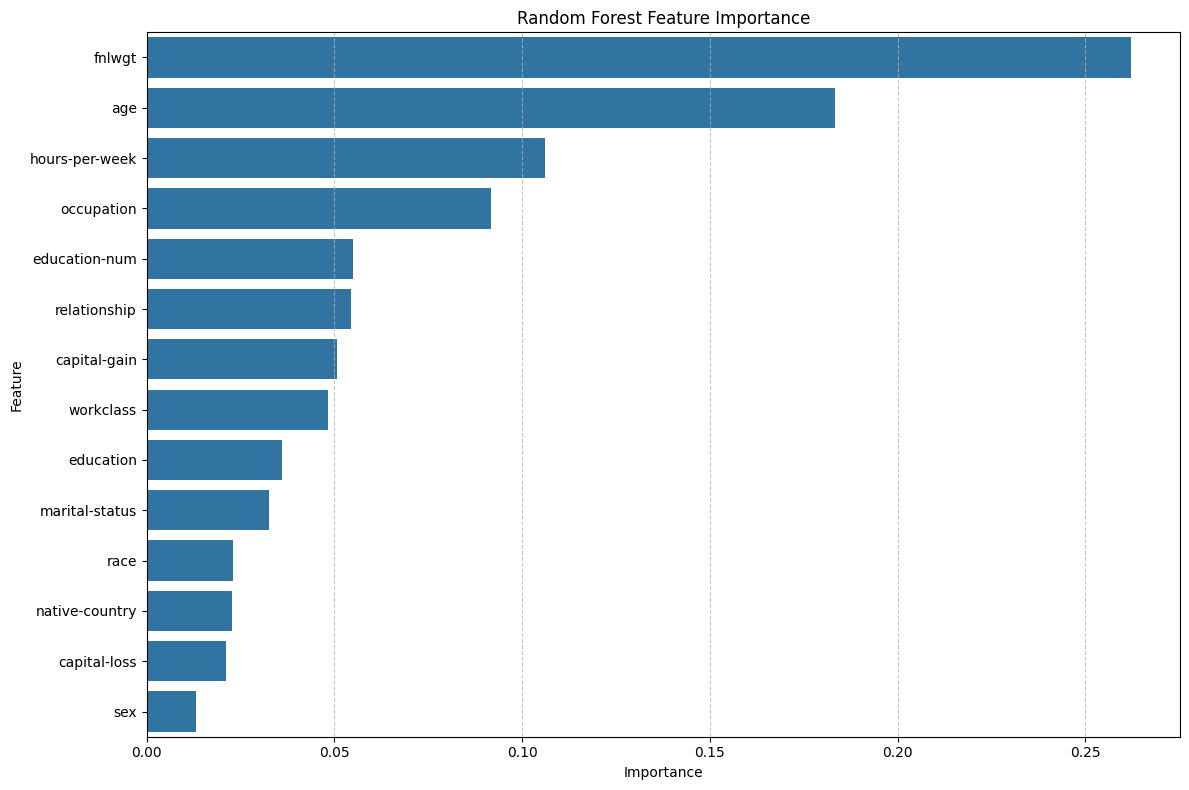

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = model_rf.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a pandas Series for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
# Akurasi
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

# Precision
print("DT Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("RF Precision:", precision_score(y_test, y_pred_rf, average='weighted'))

# Recall
print("DT Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("RF Recall:", recall_score(y_test, y_pred_rf, average='weighted'))

# F1 Score
print("DT F1:", f1_score(y_test, y_pred_dt, average='weighted'))
print("RF F1:", f1_score(y_test, y_pred_rf, average='weighted'))

# Classification Report
print("Decision Tree\n", classification_report(y_test, y_pred_dt))
print("Random Forest\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("DT Matrix\n", confusion_matrix(y_test, y_pred_dt))
print("RF Matrix\n", confusion_matrix(y_test, y_pred_rf))

DT Accuracy: 0.45052515201768933
RF Accuracy: 0.5341072415699282
DT Precision: 0.454037013411042
RF Precision: 0.46763371309324553
DT Recall: 0.45052515201768933
RF Recall: 0.5341072415699282
DT F1: 0.4522157604845398
RF F1: 0.48017873366511565
Decision Tree
               precision    recall  f1-score   support

           0       0.59      0.58      0.58      4513
           1       0.30      0.31      0.30      2232
           2       0.41      0.40      0.40      1538
           3       0.22      0.23      0.23       762

    accuracy                           0.45      9045
   macro avg       0.38      0.38      0.38      9045
weighted avg       0.45      0.45      0.45      9045

Random Forest
               precision    recall  f1-score   support

           0       0.59      0.81      0.69      4513
           1       0.28      0.11      0.15      2232
           2       0.50      0.56      0.53      1538
           3       0.22      0.08      0.12       762

    accuracy      